In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import RobustScaler, StandardScaler
import random
import os
import joblib
from category_encoders import TargetEncoder


SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [2]:
import mlflow
import mlflow.pytorch

mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Credit_Prediction_Experiments_RF")

z:\projects\AIE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
z:\projects\AIE\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:z:/projects/AIE/project/notebooks/mlruns/433861505822934159', creation_time=1778409328996, experiment_id='433861505822934159', last_update_time=1778409328996, lifecycle_stage='active', name='Credit_Prediction_Experiments_RF', tags={}, trace_location=None, workspace='default'>

In [3]:
df = pd.read_csv('../data/CreditPrediction.csv')
df = df.drop(columns=['CLIENTNUM', 'Unnamed: 19'])
df = df[(df['Customer_Age'] <= 80)]
print(f'Размер данных после удаления аномалий: {df.shape[0]}')

Размер данных после удаления аномалий: 10150


In [4]:
target_col = "Credit_Limit"
num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != target_col]
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [5]:
for col_name in cat_cols:
    df[col_name] = df[col_name].fillna('Unknown')
for col_name in num_cols:
    df[col_name] = df[col_name].fillna(df[col_name].median())

In [6]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 6090 (60.0%)
Validation: 2030 (20.0%)
Test: 2030 (20.0%)


In [7]:
cols_to_log = ['Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

In [ ]:
encoder = TargetEncoder(cols=cat_cols, smoothing=10.0, handle_unknown='value')

traget_logged = False
for col in cols_to_log:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_val[col] = np.log1p(X_val[col])
        X_test[col] = np.log1p(X_test[col])

# # Отдельно логарифмируем таргет
# y_train = np.log(y_train)
# y_val   = np.log(y_val)
# y_test  = np.log(y_test)
# traget_logged = True

X_train_enc = encoder.fit_transform(X_train, y_train)
X_val_enc = encoder.transform(X_val)
X_test_enc = encoder.transform(X_test)

joblib.dump(encoder, "../artifacts/target_encoder_rf_base_log.pkl")

['../artifacts/target_encoder_rf_base_log.pkl']

In [9]:
scaler = StandardScaler()
# scaler = RobustScaler()
X_train_scaled = X_train_enc.copy()
X_train_scaled = scaler.fit_transform(X_train_enc)

X_val_scaled = X_val_enc.copy()
X_val_scaled = scaler.transform(X_val_enc)

X_test_scaled = X_test_enc.copy()
X_test_scaled = scaler.transform(X_test_enc)

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

print("Обучение Random Forest модели...")
rf_model.fit(X_train_scaled, y_train)
print("Обучение завершено!")

import json, hashlib

config = {
    "n_estimators": 100,
    "max_depth": 20,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "target_col": target_col,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "encoder": "TargetEncoder(smoothing=10.0)",
    "scaler": str(scaler)[:-2],
    "random_state": 42,
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "data_alteration": "Only age<=80, Log of features" + ", Log of target" if traget_logged else "",
}

with open("../artifacts/RF_mlflow/rf_config.json", "w") as f:
    json.dump(config, f, indent=2)

data_path = "../data/CreditPrediction.csv"
with open(data_path, "rb") as f:
    data_hash = hashlib.md5(f.read()).hexdigest()
print(f"Data hash: {data_hash}")

Обучение Random Forest модели...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s


Обучение завершено!
Data hash: 0c491eccf4a9959c9cefab0a27497604


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.2s finished


In [ ]:
def plot_feature_importance(model, X_train, top_n=15):
    """Рисует график важности признаков"""
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = feature_importance.head(top_n)
    ax.barh(range(len(top_features)), top_features['importance'].values)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'].values)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top {top_n} Feature Importance', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return feature_importance

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


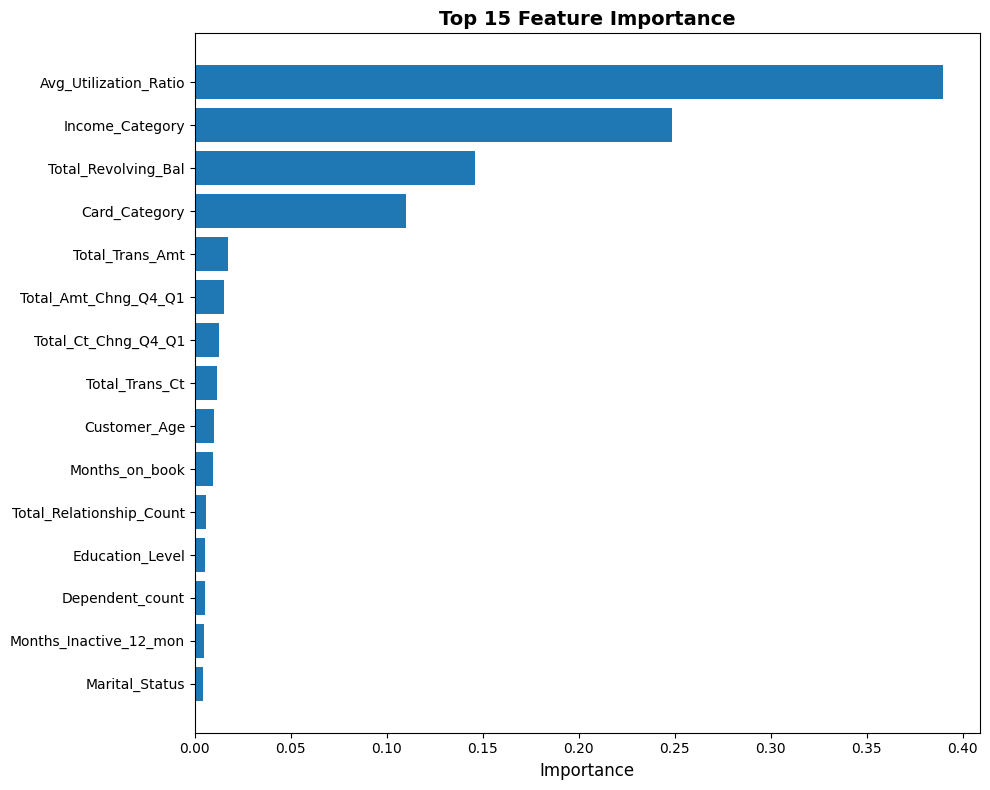

In [ ]:
y_train_pred = rf_model.predict(X_train_scaled)
y_val_pred = rf_model.predict(X_val_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

# Преобразуем обратно из логарифмической шкалы
# y_train_pred = np.exp(y_train_pred)
# y_val_pred = np.exp(y_val_pred)
# y_test_pred = np.exp(y_test_pred)

# y_train = np.exp(y_train)
# y_val = np.exp(y_val)
# y_test = np.exp(y_test)

feature_importance = plot_feature_importance(rf_model, X_train_enc, top_n=15)

In [13]:
def calculate_rf_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:   {mse:.4f}')
    print(f'  RMSE:  {rmse:.4f}')
    print(f'  MAE:   {mae:.4f}')
    print(f'  R²:    {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики Random Forest модели')
print('=' * 50)

train_rf_metrics = calculate_rf_metrics(y_train, y_train_pred, 'TRAIN')
val_rf_metrics = calculate_rf_metrics(y_val, y_val_pred, 'VALIDATION')
test_rf_metrics = calculate_rf_metrics(y_test, y_test_pred, 'TEST')

print('\n' + '=' * 50)

joblib.dump(rf_model, '../artifacts/model_random_forest.pkl')
print("\nМодель сохранена в '../artifacts/model_random_forest.pkl'")

Метрики Random Forest модели

TRAIN:
  MSE:   2354368.2766
  RMSE:  1534.3951
  MAE:   591.2170
  R²:    0.9709

VALIDATION:
  MSE:   10017055.2876
  RMSE:  3164.9732
  MAE:   1274.5856
  R²:    0.8852

TEST:
  MSE:   9430688.6639
  RMSE:  3070.9426
  MAE:   1211.0284
  R²:    0.8855


Модель сохранена в '../artifacts/model_random_forest.pkl'


In [ ]:
with mlflow.start_run(run_name="Random_forest"):
    
    mlflow.log_params(config)
    mlflow.log_param("data_hash", data_hash)
    
    mlflow.log_metrics({
        "train_mse": train_rf_metrics["MSE"],
        "train_rmse": train_rf_metrics["RMSE"],
        "train_mae": train_rf_metrics["MAE"],
        "train_r2": train_rf_metrics["R2"],
        "val_mse": val_rf_metrics["MSE"],
        "val_rmse": val_rf_metrics["RMSE"],
        "val_mae": val_rf_metrics["MAE"],
        "val_r2": val_rf_metrics["R2"],
        "test_mse": test_rf_metrics["MSE"],
        "test_rmse": test_rf_metrics["RMSE"],
        "test_mae": test_rf_metrics["MAE"],
        "test_r2": test_rf_metrics["R2"],
    })
    
    mlflow.sklearn.log_model(rf_model, "model")
    
    mlflow.log_artifact("../artifacts/RF_mlflow/rf_config.json")
    mlflow.log_artifact(data_path, "data")
    

2026/05/10 13:53:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/10 13:53:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


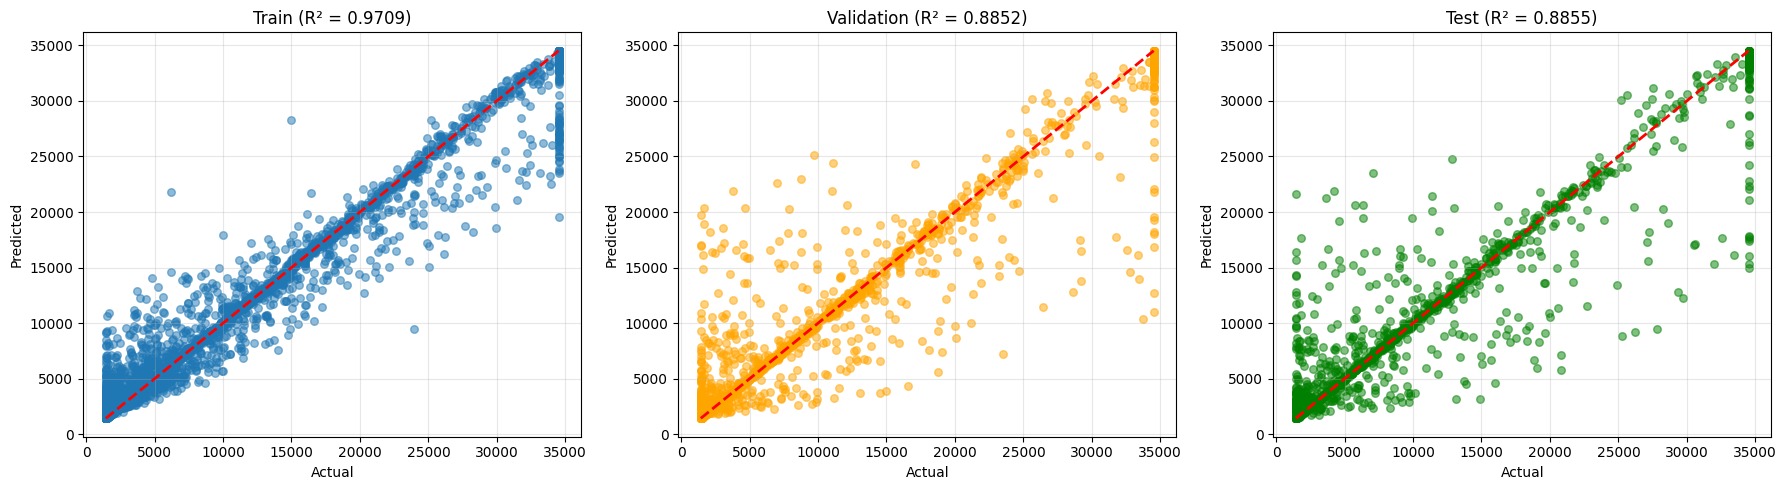

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=30)
axes[0].plot([y_train.min(), y_train.max()], 
             [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Train (R² = {train_rf_metrics["R2"]:.4f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_val, y_val_pred, alpha=0.5, s=30, color='orange')
axes[1].plot([y_val.min(), y_val.max()], 
             [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Validation (R² = {val_rf_metrics["R2"]:.4f})')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(y_test, y_test_pred, alpha=0.5, s=30, color='green')
axes[2].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Test (R² = {test_rf_metrics["R2"]:.4f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [18]:
import optuna
from sklearn.model_selection import cross_val_score
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=" * 50)
print("Тюнинг гиперпараметров Random Forest (Optuna)")
print("=" * 50)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 2000, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 40),
        'random_state': SEED
    }
    
    model = RandomForestRegressor(**params)
    # scores = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='r2', n_jobs=1)
    # return scores.mean()

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    
    val_r2 = r2_score(y_val, y_pred)
    return val_r2

study = optuna.create_study(
    direction='maximize', 
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

print("\nЗапуск оптимизации...")
study.optimize(objective, n_trials=200, n_jobs=-1, show_progress_bar=True)

print(f"\nЛучшие параметры: {study.best_params}")
print(f"Лучший R²: {study.best_value:.4f}")

Тюнинг гиперпараметров Random Forest (Optuna)

Запуск оптимизации...


Best trial: 135. Best value: 0.888313: 100%|██████████| 200/200 [10:01<00:00,  3.01s/it]


Лучшие параметры: {'n_estimators': 1050, 'max_depth': 10, 'min_samples_split': 16, 'min_samples_leaf': 5}
Лучший R²: 0.8883


In [19]:
import json, hashlib

config = {
    "n_estimators": study.best_params['n_estimators'],
    "max_depth": study.best_params['max_depth'],
    "min_samples_split": study.best_params['min_samples_split'],
    "min_samples_leaf": study.best_params['min_samples_leaf'],
    "target_col": target_col,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "encoder": "TargetEncoder(smoothing=10.0)",
    "scaler": str(scaler)[:-2],
    "random_state": 42,
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "data_alteration": "Only age<=80, Log of features" + ", Log of target" if traget_logged else "",
}

with open("../artifacts/RF_mlflow/rf_optuna_config.json", "w") as f:
    json.dump(config, f, indent=2)

data_path = "../data/CreditPrediction.csv"
with open(data_path, "rb") as f:
    data_hash = hashlib.md5(f.read()).hexdigest()
print(f"Data hash: {data_hash}")

Data hash: 0c491eccf4a9959c9cefab0a27497604


In [20]:
best_rf = RandomForestRegressor(**study.best_params, random_state=SEED)
best_rf.fit(X_train_scaled, y_train)

y_train_pred = best_rf.predict(X_train_scaled)
y_val_pred = best_rf.predict(X_val_scaled)
y_test_pred = best_rf.predict(X_test_scaled)

print(f"\nValidation | R²: {r2_score(y_val, y_val_pred):.4f} | RMSE: {mean_squared_error(y_val, y_val_pred):.4f}")
print(f"Test      | R²: {r2_score(y_test, y_test_pred):.4f} | RMSE: {mean_squared_error(y_test, y_test_pred):.4f}")

joblib.dump(best_rf, '../artifacts/model_random_forest_best_optuna.pkl')
print("\nМодель сохранена")


Validation | R²: 0.8883 | RMSE: 9741582.7186
Test      | R²: 0.8855 | RMSE: 9433034.6546

Модель сохранена


In [21]:
def calculate_rf_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:   {mse:.4f}')
    print(f'  RMSE:  {rmse:.4f}')
    print(f'  MAE:   {mae:.4f}')
    print(f'  R²:    {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики Random Forest модели')
print('=' * 50)

train_rf_metrics = calculate_rf_metrics(y_train, y_train_pred, 'TRAIN')
val_rf_metrics = calculate_rf_metrics(y_val, y_val_pred, 'VALIDATION')
test_rf_metrics = calculate_rf_metrics(y_test, y_test_pred, 'TEST')

print('\n' + '=' * 50)

joblib.dump(best_rf, '../artifacts/model_random_forest.pkl')
print("\nМодель сохранена в '../artifacts/model_random_forest.pkl'")

Метрики Random Forest модели

TRAIN:
  MSE:   7212518.7776
  RMSE:  2685.6133
  MAE:   1076.2576
  R²:    0.9109

VALIDATION:
  MSE:   9741582.7186
  RMSE:  3121.1509
  MAE:   1311.3765
  R²:    0.8883

TEST:
  MSE:   9433034.6546
  RMSE:  3071.3246
  MAE:   1265.9953
  R²:    0.8855


Модель сохранена в '../artifacts/model_random_forest.pkl'


In [ ]:
with mlflow.start_run(run_name="Random_forest"):
    
    mlflow.log_params(config)
    mlflow.log_param("data_hash", data_hash)
    
    mlflow.log_metrics({
        "train_mse": train_rf_metrics["MSE"],
        "train_rmse": train_rf_metrics["RMSE"],
        "train_mae": train_rf_metrics["MAE"],
        "train_r2": train_rf_metrics["R2"],
        "val_mse": val_rf_metrics["MSE"],
        "val_rmse": val_rf_metrics["RMSE"],
        "val_mae": val_rf_metrics["MAE"],
        "val_r2": val_rf_metrics["R2"],
        "test_mse": test_rf_metrics["MSE"],
        "test_rmse": test_rf_metrics["RMSE"],
        "test_mae": test_rf_metrics["MAE"],
        "test_r2": test_rf_metrics["R2"],
    })
    
    mlflow.sklearn.log_model(best_rf, "model")
    
    mlflow.log_artifact("../artifacts/RF_mlflow/rf_optuna_config.json")
    mlflow.log_artifact(data_path, "data")
    

2026/05/10 15:48:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/10 15:48:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


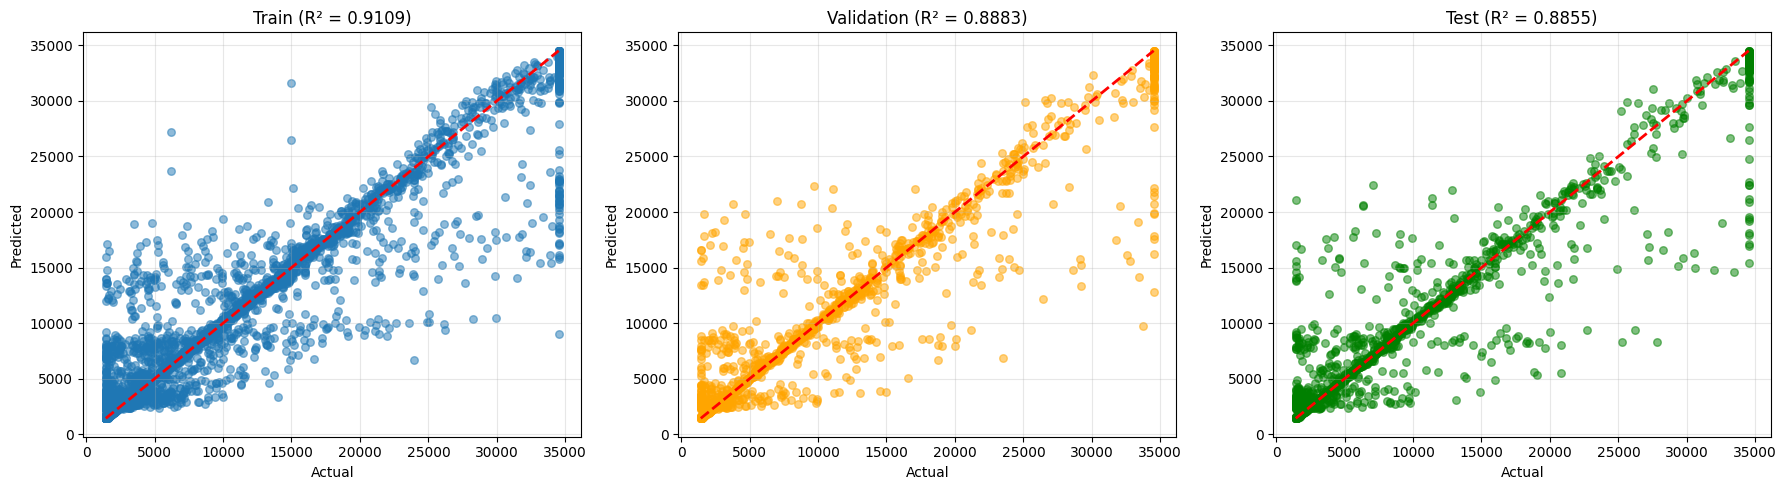

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=30)
axes[0].plot([y_train.min(), y_train.max()], 
             [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Train (R² = {train_rf_metrics["R2"]:.4f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_val, y_val_pred, alpha=0.5, s=30, color='orange')
axes[1].plot([y_val.min(), y_val.max()], 
             [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Validation (R² = {val_rf_metrics["R2"]:.4f})')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(y_test, y_test_pred, alpha=0.5, s=30, color='green')
axes[2].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Test (R² = {test_rf_metrics["R2"]:.4f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
